<a href="https://colab.research.google.com/github/adalbertii/Track-optimization/blob/main/vrp_full_soultion_10_06_2026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys

# Install ortools if not already installed
!{sys.executable} -m pip install ortools
!{sys.executable} -m pip install numpy pandas matplotlib networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 whi

In [2]:
import sys
!{sys.executable} -m pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.1 MB/s eta 0:00:00


## Helper Functions for VRP

This section defines all the supporting functions needed for the Vehicle Routing Problem. This includes functions for generating problem data (distance matrix, demands, time windows, vehicle capacities) and for visualizing the results.

In [3]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import networkx as nx
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
import os

def create_vrp_report(filename, data, df_results, plot_image_path, df_vehicle_summaries):
    """Generates a PDF report containing VRP analysis details."""
    doc = SimpleDocTemplate(filename, pagesize=letter)
    styles = getSampleStyleSheet()
    story = []

    # Title Page
    story.append(Paragraph('<b>Vehicle Routing Problem Analysis Report</b>', styles['h1']))
    story.append(Spacer(1, 0.2 * inch))
    story.append(Paragraph(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}", styles['Normal']))
    story.append(Spacer(1, 0.5 * inch))
    story.append(Paragraph('<b>Generated by: Wojciech Michalski</b>', styles['Normal']))
    story.append(PageBreak())

    # VRP Configuration Parameters
    story.append(Paragraph('<b>1. VRP Configuration Parameters</b>', styles['h2']))
    story.append(Paragraph(f"Number of Nodes: {len(data['distance_matrix'])}", styles['Normal']))
    story.append(Paragraph(f"Number of Vehicles: {data['num_vehicles']}", styles['Normal']))
    story.append(Paragraph(f"Depot Node: {data['depot']}", styles['Normal']))
    story.append(Paragraph(f"Random Seed (for data generation): {42}", styles['Normal'])) # Using hardcoded seed for report consistency
    story.append(Spacer(1, 0.2 * inch))

    # Distance Matrix
    story.append(Paragraph('<b>2. Distance Matrix</b>', styles['h2']))
    # Headers for columns: 'Node' for the row index, then column indices
    dist_data = [['Node'] + [str(i) for i in range(len(data['distance_matrix']))]]
    for i, row in enumerate(data['distance_matrix']):
        # Prepend row index and convert all values to string for the table
        dist_data.append([str(i)] + [str(x) for x in row])

    dist_table = Table(dist_data)
    dist_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(dist_table)
    story.append(Spacer(1, 0.2 * inch))

    # Node Demands
    story.append(Paragraph('<b>3. Node Demands</b>', styles['h2']))
    demands_data = [['Node', 'Demand']]
    for i, demand in enumerate(data['demands']):
        demands_data.append([i, demand])
    demands_table = Table(demands_data)
    demands_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(demands_table)
    story.append(Spacer(1, 0.2 * inch))

    # Node Time Windows
    story.append(Paragraph('<b>4. Node Time Windows</b>', styles['h2']))
    tw_data = [['Node', 'Start Time', 'End Time']]
    for i, tw in enumerate(data['time_windows']):
        tw_data.append([i, tw[0], tw[1]])
    tw_table = Table(tw_data)
    tw_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(tw_table)
    story.append(Spacer(1, 0.2 * inch))

    # Vehicle Capacities
    story.append(Paragraph('<b>5. Vehicle Capacities</b>', styles['h2']))
    cap_data = [['Vehicle', 'Capacity']]
    for i, capacity in enumerate(data['vehicle_capacities']):
        cap_data.append([i + 1, capacity])
    cap_table = Table(cap_data)
    cap_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(cap_table)
    story.append(PageBreak())

    # Solution Overview (with vehicle summaries)
    story.append(Paragraph('<b>6. VRP Solution Overview</b>', styles['h2']))
    total_distance_all_vehicles = df_vehicle_summaries['Distance'].sum()
    story.append(Paragraph(f"Total distance for all routes: {total_distance_all_vehicles} units", styles['Normal']))
    story.append(Spacer(1, 0.1 * inch))
    story.append(Paragraph('<b>Individual Vehicle Summaries:</b>', styles['Normal']))

    vehicle_summary_data = [list(df_vehicle_summaries.columns)] + df_vehicle_summaries.values.tolist()
    vehicle_summary_table = Table(vehicle_summary_data)
    vehicle_summary_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(vehicle_summary_table)
    story.append(Spacer(1, 0.2 * inch))

    # Route Plot
    story.append(Paragraph('<b>7. VRP Routes Visualization</b>', styles['h2']))
    if os.path.exists(plot_image_path):
        img = Image(plot_image_path)
        # Scale image to fit within page width, maintaining aspect ratio
        img_width, img_height = img.drawWidth, img.drawHeight
        max_width = letter[0] - 2 * inch # Account for 1-inch margins on both sides
        if img_width > max_width:
            scale_factor = max_width / img_width
            img.drawWidth = img_width * scale_factor
            img.drawHeight = img_height * scale_factor
        story.append(img)
    else:
        story.append(Paragraph('Route visualization image not found.', styles['Normal']))
    story.append(PageBreak())

    # Tabulated Results
    story.append(Paragraph('<b>8. Detailed VRP Analysis Results</b>', styles['h2']))

    # Prepare data for table: header and rows
    table_data = [list(df_results.columns)] + df_results.values.tolist()

    # Create the table
    # Auto-adjust column widths
    col_widths = [None] * len(df_results.columns)
    results_table = Table(table_data, colWidths=col_widths)

    # Style the table
    results_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 9), # Header font size
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('FONTSIZE', (0, 1), (-1, -1), 8), # Content font size
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    story.append(results_table)

    doc.build(story)

def create_data_model(num_nodes, num_vehicles, depot_node, distance_matrix, demands, time_windows, vehicle_capacities):
    """Stores the data for the problem."""
    data = {}
    data['distance_matrix'] = distance_matrix
    data['demands'] = demands
    data['time_windows'] = time_windows
    data['num_vehicles'] = num_vehicles
    data['vehicle_capacities'] = vehicle_capacities # Capacities for each vehicle
    data['depot'] = depot_node
    return data

def generate_distance_matrix(num_nodes, seed=42):
    """
    Generates a random symmetric distance matrix for `num_nodes`.
    Distances are integers between 10 and 100.
    The diagonal elements are 0.
    """
    random.seed(seed)
    np.random.seed(seed)
    matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            dist = random.randint(10, 100)
            matrix[i, j] = dist
            matrix[j, i] = dist # Ensure symmetry
    return matrix.tolist()

def generate_demands(num_nodes, seed=42):
    """
    Generates random demands for each node. Depot (node 0) has 0 demand.
    Demands are integers between 5 and 20.
    """
    random.seed(seed)
    demands = [0] + [random.randint(5, 20) for _ in range(num_nodes - 1)]
    return demands

def generate_time_windows(num_nodes, max_time_window_start=500, time_window_duration=100, seed=42):
    """
    Generates random time windows for each node.
    Depot (node 0) typically has a larger time window from 0 to a very high value.
    Other nodes have random start times and a fixed duration.
    """
    random.seed(seed)
    time_windows = []
    # Depot time window (from start to a very late time)
    time_windows.append((0, max_time_window_start + time_window_duration * num_nodes))
    for _ in range(num_nodes - 1):
        start = random.randint(0, max_time_window_start)
        end = start + time_window_duration # Fixed duration for simplicity
        time_windows.append((start, end))
    return time_windows

def generate_vehicle_capacities(num_vehicles, max_capacity=100, seed=42):
    """
    Generates random capacities for each vehicle.
    """
    random.seed(seed)
    capacities = [random.randint(max_capacity // 2, max_capacity) for _ in range(num_vehicles)]
    return capacities

def visualize_distance_matrix_and_constraints(distance_matrix, demands, time_windows, vehicle_capacities):
    """
    Visualizes the distance matrix as a DataFrame and prints constraints.
    """
    print("\n--- Distance Matrix ---")
    df_dist = pd.DataFrame(distance_matrix)
    print(df_dist.to_string())

    print("\n--- Node Demands ---")
    df_demands = pd.DataFrame({'Node': range(len(demands)), 'Demand': demands})
    print(df_demands.to_string(index=False))

    print("\n--- Node Time Windows ---")
    df_tw = pd.DataFrame({'Node': range(len(time_windows)), 'Start': [tw[0] for tw in time_windows], 'End': [tw[1] for tw in time_windows]})
    print(df_tw.to_string(index=False))

    print("\n--- Vehicle Capacities ---")
    df_caps = pd.DataFrame({'Vehicle': range(len(vehicle_capacities)), 'Capacity': vehicle_capacities})
    print(df_caps.to_string(index=False))

def plot_routes(data, manager, routing, solution):
    """
    Plots the VRP routes using networkx and matplotlib.
    This function prepares the plot on the current matplotlib figure.
    It does NOT call plt.show() or plt.savefig().
    """
    G = nx.DiGraph()
    pos = {i: (random.random(), random.random()) for i in range(len(data['distance_matrix']))} # Random positions for nodes

    # Add nodes
    for i in range(len(data['distance_matrix'])):
        G.add_node(i, demand=data['demands'][i], time_window=data['time_windows'][i])

    colors = plt.get_cmap('tab10', data['num_vehicles']) # Corrected to use plt.get_cmap for discrete colors

    # Draw nodes first to ensure they are visible
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Add edges for each vehicle route
    # total_distance = 0 # This variable is local and not used for PDF output anymore
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_nodes = [manager.IndexToNode(index)]
        # route_dist = 0 # This is now handled in main for summary generation

        # Collect edges for this specific vehicle for plotting
        vehicle_edges = []

        while not routing.IsEnd(index):
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            current_node = manager.IndexToNode(index)
            route_nodes.append(current_node)

            # This route_dist is for internal plotting, not the final summary
            # route_dist += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

            if previous_index is not None and index is not None:
                # Only add edge if it's a valid segment of the route
                if manager.IndexToNode(previous_index) < len(data['distance_matrix']) and current_node < len(data['distance_matrix']):
                    vehicle_edges.append((manager.IndexToNode(previous_index), current_node))

        # Draw edges for this vehicle's route
        nx.draw_networkx_edges(G, pos, edgelist=vehicle_edges, edge_color=colors(vehicle_id),
                               width=2, arrowsize=15)

    # Create custom legend handles, because networkx.draw_networkx_edges doesn't return artists with labels easily
    legend_handles = []
    for vehicle_id in range(data['num_vehicles']):
        legend_handles.append(plt.Line2D([0], [0], color=colors(vehicle_id), lw=2, label=f'Vehicle {vehicle_id + 1}'))

    plt.title('Vehicle Routing Problem Routes')
    plt.legend(handles=legend_handles, title='Vehicle Routes', loc='upper left', bbox_to_anchor=(1, 1)) # Explicit legend
    plt.grid(True)
    plt.axis('off')

## Main VRP Solving Function

This section contains the core logic for solving the VRP using `ortools`. It sets up the routing model, defines dimensions for capacity and time windows, and configures the search parameters to find an optimal or near-optimal solution.

In [4]:
def solve_vrp(data):
    """Solves the VRP problem with capacity and time window constraints."""

    # Create the routing index manager.
    # The manager handles the conversion between node indices and solver indices.
    manager = pywrapcp.RoutingIndexManager(
        len(data['distance_matrix']), data['num_vehicles'], data['depot'])

    # Create Routing Model.
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback for distances.
    # This callback returns the travel cost (distance) between two nodes.
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc.
    # The solver aims to minimize the total cost (total distance).
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Capacity constraint.
    # This constraint ensures that the total demand of nodes visited by a vehicle
    # does not exceed its capacity.
    def demand_callback(from_index):
        """Returns the demand of the node."""
        from_node = manager.IndexToNode(from_index)
        return data['demands'][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    # Add a dimension for vehicle capacity.
    # 'Capacity' is the dimension name, `demand_callback_index` provides the demand,
    # `0` is the initial load (empty),
    # `data['vehicle_capacities']` are the maximum capacities for each vehicle,
    # `True` means the cumul var is reset to 0 at the start of each route (depot).
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        data['vehicle_capacities'],  # vehicle maximum capacities
        True,  # start cumul to zero
        'Capacity')

    # Add Time Window constraint.
    # This ensures that each vehicle arrives at a node within its specified time window.
    def time_callback(from_index, to_index):
        """Returns the travel time between the two nodes."""
        # Assuming travel time is directly proportional to distance for simplicity.
        # Could be extended with speed factors.
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data['distance_matrix'][from_node][to_node] # Using distance as time

    time_callback_index = routing.RegisterTransitCallback(time_callback)

    # Add a dimension for time.
    # 'Time' is the dimension name, `time_callback_index` provides travel times,
    # `0` is the initial time (start at 0),
    # `data['time_windows'][-1][1]` is a large maximum time for all vehicles to ensure feasibility initially.
    # `False` means the cumul var is not reset to 0 at the start of each route (time accumulates).
    routing.AddDimension(
        time_callback_index,
        3000,  # maximum slack (waiting time at nodes)
        3000,  # maximum time for all vehicles
        False,  # Don't start cumul to zero.
        'Time')
    time_dimension = routing.GetDimensionOrDie('Time')

    # Add time window constraints for each node.
    # For each node, the arrival time must be within its time window.
    for node_idx, time_window in enumerate(data['time_windows']):
        if node_idx == data['depot']:
            continue # Depot usually has a large or special time window
        index = manager.NodeToIndex(node_idx)
        time_dimension.CumulVar(index).SetRange(time_window[0], time_window[1])

    # Add time window constraints for each vehicle's start and end at the depot.
    for vehicle_id in range(data['num_vehicles']):
        start_index = routing.Start(vehicle_id)
        time_dimension.CumulVar(start_index).SetRange(
            data['time_windows'][data['depot']][0],
            data['time_windows'][data['depot']][1])
        end_index = routing.End(vehicle_id)
        time_dimension.CumulVar(end_index).SetRange(
            data['time_windows'][data['depot']][0],
            data['time_windows'][data['depot']][1])

    # Allow the solver to drop nodes (make them unvisited) if necessary, with a penalty.
    # This helps in finding a feasible solution even if some nodes cannot be visited.
    for node_idx in range(1, len(data['distance_matrix'])):
        if node_idx == data['depot']:
            continue
        penalty = 1000  # Penalty for not visiting a node
        routing.AddDisjunction([manager.NodeToIndex(node_idx)], penalty)

    # Set search parameters and heuristics.
    # Use a First Solution Strategy to quickly find an initial solution.
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC)

    # Use a Local Search Metaheuristic to improve the initial solution.
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH)
    search_parameters.time_limit.FromSeconds(5) # Limit search time to 5 seconds

    # Solve the problem.
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print("Solution found!")
        return manager, routing, solution
    else:
        print('No solution found!')
        return None, None, None

## Main Execution Block

This section orchestrates the entire VRP process. It defines problem parameters, generates random data based on these parameters, prepares the data model, calls the solver, visualizes the results, and saves them to a CSV file.

Starting Vehicle Routing Problem analysis...
Generating data for 55 nodes and 10 vehicles...
Distance matrix saved to 'matrix_distance_15.csv'

Visualizing generated constraints...

--- Distance Matrix ---
    0    1   2   3    4   5   6    7    8    9    10  11  12   13  14  15  16   17  18  19   20  21   22  23  24  25   26   27  28   29  30   31   32  33   34   35  36  37   38  39  40   41  42  43   44   45  46  47  48  49  50   51  52  53   54
0    0   91  24  13   45  41  38   27   23   96   79  21  85   64  14  13  21   37  39  74   87  13   81  35  93  99   79   63  38   67  85   45   10  30   99   64  53  45   29  37  53   23  21  58   22   55  54  87  43  15  68   78  25  58   20
1   91    0  80  47   90  89  56   83   34  100   18  15  94   39  47  20  39   22  58  45   68  91   56  30  57  55   36   95  44   99  97   92   19  87   91   31  78  41   30  69  58   44  91  98   81   38  97  51  17  39  14   50  61  44   18
2   24   80   0  37   82  50  37   93   73   60   92  68

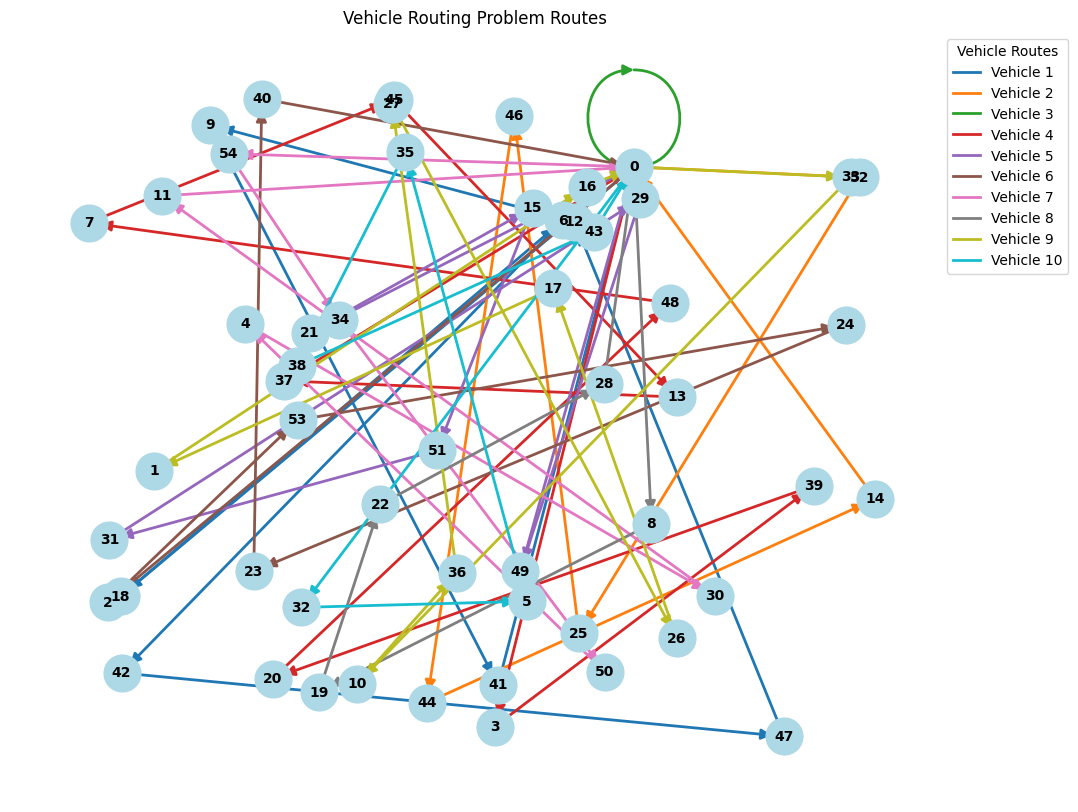


Generating PDF report...
PDF report 'vrp_analysis_report.pdf' generated successfully.

Vehicle Routing Problem analysis complete.


In [5]:
def main():
    """Entry point of the VRP program."""
    print("Starting Vehicle Routing Problem analysis...")

    # --- Configuration Parameters ---
    num_nodes = 55          # Total number of locations (including depot)
    num_vehicles = 10        # Number of vehicles available
    depot_node = 0          # The index of the depot node (start and end point for vehicles)
    random_seed = 42        # Seed for reproducibility of random data generation

    # --- Data Generation ---
    print(f"Generating data for {num_nodes} nodes and {num_vehicles} vehicles...")
    distance_matrix = generate_distance_matrix(num_nodes, seed=random_seed)
    demands = generate_demands(num_nodes, seed=random_seed)
    time_windows = generate_time_windows(num_nodes, seed=random_seed)
    vehicle_capacities = generate_vehicle_capacities(num_vehicles, seed=random_seed)

    # Save distance matrix to CSV
    df_distance = pd.DataFrame(distance_matrix)
    df_distance.to_csv('matrix_distance_15.csv', index=False)
    print("Distance matrix saved to 'matrix_distance_15.csv'")

    # --- Prepare Data Model for OR-Tools ---
    data = create_data_model(num_nodes, num_vehicles, depot_node,
                             distance_matrix, demands, time_windows, vehicle_capacities)

    # --- Visualize Constraints ---
    print("\nVisualizing generated constraints...")
    visualize_distance_matrix_and_constraints(distance_matrix, demands, time_windows, vehicle_capacities)

    # --- Solve the VRP ---
    print("\nAttempting to solve the VRP...")
    manager, routing, solution = solve_vrp(data)

    if solution:
        # --- Extract and Save Results ---
        print("\nExtracting and saving analysis results...")
        routes_data = []
        vehicle_summaries_for_pdf = [] # To store summaries for PDF report

        for vehicle_id in range(data['num_vehicles']):
            index = routing.Start(vehicle_id)
            route_nodes = []
            route_dist = 0
            time_dimension = routing.GetDimensionOrDie('Time')

            while not routing.IsEnd(index):
                node_index = manager.IndexToNode(index)
                route_nodes.append(node_index)

                # Get values from solution
                load_var = routing.GetDimensionOrDie('Capacity').CumulVar(index)

                previous_index = index
                index = solution.Value(routing.NextVar(index))

                segment_distance = data['distance_matrix'][manager.IndexToNode(previous_index)][manager.IndexToNode(index)]
                route_dist += segment_distance

                routes_data.append({
                    'Vehicle': vehicle_id + 1,
                    'Node_From': manager.IndexToNode(previous_index),
                    'Node_To': manager.IndexToNode(index),
                    'Distance': segment_distance,
                    'Cumulative_Distance': route_dist, # Cumulative distance for THIS vehicle's route so far
                    'Load_At_Node': solution.Value(load_var),
                    'Arrival_Time': solution.Value(time_dimension.CumulVar(index)), # Arrival time at current node
                    'Time_Window_Start': data['time_windows'][manager.IndexToNode(previous_index)][0],
                    'Time_Window_End': data['time_windows'][manager.IndexToNode(previous_index)][1]
                })

            # Add the last node (depot) in the route for the summary
            node_index = manager.IndexToNode(index)
            route_nodes.append(node_index)

            final_load_at_depot = solution.Value(routing.GetDimensionOrDie('Capacity').CumulVar(routing.End(vehicle_id)))
            final_time_at_depot = solution.Value(time_dimension.CumulVar(routing.End(vehicle_id)))

            vehicle_summaries_for_pdf.append({
                'Vehicle': vehicle_id + 1,
                'Route': ' -> '.join(map(str, route_nodes)),
                'Distance': route_dist, # Total distance for this vehicle
                'Load': final_load_at_depot,
                'Time': final_time_at_depot
            })

            print(f"Vehicle {vehicle_id + 1}: Route {' -> '.join(map(str, route_nodes))}, " +
                  f"Distance: {route_dist}, Load: {final_load_at_depot}, "+
                  f"Time: {final_time_at_depot}")

        df_results = pd.DataFrame(routes_data)
        df_results.to_csv('vrp_analysis_results.csv', index=False)
        print("VRP analysis results saved to 'vrp_analysis_results.csv'")

        df_vehicle_summaries = pd.DataFrame(vehicle_summaries_for_pdf)

        # --- Visualize Results ---
        print("\nPlotting analysis results...")
        plot_image_path = 'vrp_routes_plot.jpg'

        # Call plot_routes. It will create a matplotlib figure internally and draw on it.
        plt.figure(figsize=(12, 10)) # Ensure a fresh figure is created
        plot_routes(data, manager, routing, solution)
        plt.savefig(plot_image_path, bbox_inches='tight', format='jpeg', dpi=100) # Save as JPEG with reduced DPI
        plt.show() # Display the plot inline
        plt.close() # Close the figure to avoid displaying it in notebook output, and release memory

        # --- Generate PDF Report ---
        print("\nGenerating PDF report...")
        create_vrp_report('vrp_analysis_report.pdf', data, df_results, plot_image_path, df_vehicle_summaries)
        print("PDF report 'vrp_analysis_report.pdf' generated successfully.")

        # Clean up temporary image file
        if os.path.exists(plot_image_path):
            os.remove(plot_image_path)

    print("\nVehicle Routing Problem analysis complete.")

if __name__ == '__main__':
    main()